# TERRA: node perturbation on held-out CRC Myeloids

Adapts the [TERRA perturbation tutorial](https://github.com/Lotfollahi-lab/terra/blob/main/docs/notebooks/perturbation_tutorial.ipynb)
to the **node-perturbation** task used in this repo's LOO benchmark, on `crc_232` with **Myeloid** held out
in the cancer (CRC) region — the same slide, cell type and holdout as `cellina/docs/tutorial.ipynb`.

**TERRA-only.** No cellina import anywhere; the only shared code is `scripts/counterfactual_analysis.py`,
which depends on nothing but numpy/scanpy/decoupler/scipy/pandas/sklearn.

### How this differs from the TERRA tutorial

TERRA is a **JEPA** model: pretraining predicts *embeddings* of masked blocks, never counts, so there is no
reconstruction head. The published bundles (`model_checkpoint.pt`, `model_config.yaml`, `token_dictionary.pkl`,
`ensembl_dictionary.pkl`, `gene_count_dictionary.pkl`) ship **no decoder**. The tutorial therefore stops at a
per-niche W2 distance between unperturbed and perturbed embeddings.

Our benchmark is scored in **expression space** (Pearson *r* between observed and predicted logFC over the top
DE genes), so we add the one missing piece: `terra.training.decode`, a frozen-encoder NB probe
(`embedding -> negative-binomial mean`). TERRA itself is never fine-tuned.

### Design decisions (each verified against the TERRA source)

| Decision | Choice | Why |
|---|---|---|
| Readout | train `CountDecoder`, decode perturbed embeddings | JEPA has no native decoder; this is the only expression-space readout |
| Embedding | **`spatial_cell_emb`** | see the warning below — `cell_emb` cannot work |
| Coordinates | `px * 0.12028` -> `obsm['terra_spatial']` | µm, as in the cellina tutorial's `bandwidth=100/0.12028` |
| Perturbation | **additive** shift in log1p space | `gene_expr` is `log1p(count)`; see §7 |
| Gene space | all ~18.9k genes in, 2000 HVGs out of the decoder | TERRA gets full context; decoder head stays learnable |
| Holdout | CRC Myeloids excluded from **decoder** training | TERRA is zero-shot, so the decoder is the only leak path |

> ### ⚠️ `cell_emb` is provably invariant to neighbourhood perturbation
>
> `embed_dataset` runs two passes. From the `forward` docstring in `models/gene_transformers.py`:
> *"`need_cell_only_context`: if `True`, also run a second pass where queries in `[0:seq_len_cell)` **cannot
> attend to keys in `[seq_len_cell:)`**."*
>
> ```
> cell_emb         = mean(cell_only_ctx, cell_mask)          # own tokens, NO neighbour attention
> spatial_cell_emb = mean(full_ctx,      cell_mask)          # own tokens, full attention
> neighborhood_emb = mean(full_ctx,      neighborhood_mask)  # neighbour tokens
> ```
>
> `terra/training/decode.py` defaults to `--embed-key cell_emb`. Taking that default here would produce an
> exactly-zero counterfactual that looks like "TERRA cannot do node perturbation". We use `spatial_cell_emb`
> and **assert** in §9 that `cell_emb` is bit-identical between the base and perturbed passes.

## 0. GPU selection

`embed_dataset` hardcodes `cuda:0` and takes no device argument, so the GPU must be chosen via `CUDA_VISIBLE_DEVICES` **before** torch is imported.

In [1]:
import os
# Physical GPU 1 (checked with nvidia-smi: it was the freer of the two RTX 4090s).
# Must be set before torch is imported -- embed_dataset() hardcodes cuda:0, so after
# this line "cuda:0" IS physical GPU 1.
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [3]:
import sys, json, pickle, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from datasets import load_from_disk

from terra import download_pretrained
from terra.inference import harmonize_adata, tokenize_adata, embed_dataset
from terra.training.decode import apply_count_decoder

# Metric helpers shared with the other LOO baselines (cellina / mintflow / spatialprop).
# This module imports only numpy/scanpy/decoupler/scipy/pandas/sklearn -- no cellina, no scvi.
sys.path.append("../../../scripts")
from counterfactual_analysis import (
    get_lfc, precision, direction_match,
    get_global_perturbation_logfc,
)

print("torch", torch.__version__, "| cuda", torch.version.cuda, "| available:", torch.cuda.is_available())
assert torch.cuda.is_available(), "TERRA requires a GPU"
print("visible GPU:", torch.cuda.get_device_name(0))

/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setu

torch 2.5.1+cu121 | cuda 12.1 | available: True
visible GPU: NVIDIA GeForce RTX 4090


/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


## 1. Configuration

In [4]:
SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

MODEL_REPO = "lotfollahi-lab/TERRA-112M"   # swap to TERRA-96M by changing this line only
DATA_ROOT  = os.environ.get("DATA_ROOT", "../../..")
DATA_PATH  = f"{DATA_ROOT}/data/crc_wt_cosmx/crc_232.h5ad"

CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)
OUT   = Path("output"); OUT.mkdir(exist_ok=True)

# Annotation keys (identical to cellina/docs/tutorial.ipynb)
LABELS_KEY, DOMAINS_KEY = "coarse_type", "typ"
HOLDOUT_CT     = "Epithelial"
CONTROL_DOMAIN = "232_REF"
TARGET_DOMAIN  = "232_CRC"

# Every artifact that depends on the holdout is keyed by this. The tokenised and
# embedding caches are NOT -- they cover all cells and are shared across cell types.
TAG = HOLDOUT_CT.lower()

# Benchmark parity with notebooks/loo_benchmarks/cellina_node_pert.ipynb
N_PERT_GENES = 200
N_DEG        = 50

# CosMx pixel -> micron. The cellina tutorial encodes the same factor as
# `bandwidth = 100 / 0.12028` px for a 100 um bandwidth.
PX_TO_UM = 0.12028

EMBED_BATCH_SIZE = 32   # 2816-token sequences on a 24 GB 4090; raise if headroom allows
TOKENIZE_NPROC   = 16

## 2. Load and label

Same coarse cell-type map as the cellina tutorial: `epi1-4` etc. are subtypes of one major type.

In [5]:
adata = sc.read_h5ad(DATA_PATH)
adata.obs_names_make_unique()

label_to_coarse = {
    "epi1": "Epithelial", "epi2": "Epithelial", "epi3": "Epithelial", "epi4": "Epithelial",
    "fib1": "Fibroblast", "fib2": "Fibroblast",
    "EC": "Endothelial", "SMC": "Smooth_muscle",
    "BC": "B_cell",
    "PC_IgA": "Plasma_cell", "PC_IgG": "Plasma_cell", "PC_IgM": "Plasma_cell",
    "TC": "T_cell",
    "mye1": "Myeloid", "mye2": "Myeloid",
    "mast": "Mast_cell",
}
adata.obs[LABELS_KEY] = adata.obs["ist"].map(label_to_coarse)
adata = adata[~adata.obs[DOMAINS_KEY].isna()]
adata = adata[~adata.obs[LABELS_KEY].isna()].copy()

# TERRA matches cells by obs['cell_id'] throughout (tokenize -> embed -> perturb).
# The file already ships a 'cell_id' column and harmonize_adata only creates one when
# absent, so set it explicitly from the (unique) obs_names and keep it as str.
adata.obs["cell_id"] = adata.obs_names.astype(str)
assert adata.obs["cell_id"].is_unique

# CSC -> CSR: the tokenizer iterates cells (rows).
import scipy.sparse as sp
if sp.issparse(adata.X):
    adata.X = adata.X.tocsr()

print(adata.shape)
pd.crosstab(adata.obs[LABELS_KEY], adata.obs[DOMAINS_KEY])

(111989, 18936)


typ,232_CRC,232_REF
coarse_type,,
Endothelial,4994,1772
Epithelial,37319,12646
Fibroblast,20695,2881
Myeloid,5035,1033
Plasma_cell,7265,8387
Smooth_muscle,4157,1528
T_cell,2793,1484


## 3. Spatial coordinates

The tokenizer reads `adata.obsm['spatial']` (hardcoded, and passed to `squidpy.gr.spatial_neighbors`), and
`rel_x/rel_y` are raw coordinate **differences** fed to `sincos(omega * coord)` with no normalisation anywhere.
So units matter whenever the model uses `cell_pos_enc: coord`.

We build a new `obsm['terra_spatial']` in microns and never touch any existing key.

> For **TERRA-112M** specifically this is belt-and-braces: its config sets `cell_pos_enc: segment`, so the model
> consumes only the segment index, and the coordinates affect nothing but the kNN graph and the distance
> *ordering* of the 10 neighbours — both invariant to a positive rescaling. It matters for TERRA-96M,
> which uses `cell_pos_enc: coord`.

In [6]:
assert "spatial" not in adata.obsm, "refusing to overwrite an existing obsm['spatial']"

px = adata.obs[["CenterX_global_px", "CenterY_global_px"]].to_numpy(dtype=np.float64)
adata.obsm["terra_spatial"] = px * PX_TO_UM          # microns

# The tokenizer only ever reads obsm['spatial']; point it at the microns array.
adata.obsm["spatial"] = adata.obsm["terra_spatial"]

ext = np.ptp(adata.obsm["terra_spatial"], axis=0)
print(f"tissue extent: {ext[0]:.0f} x {ext[1]:.0f} um")

tissue extent: 4593 x 5624 um


## 4. Download the model and harmonize

Passing the bundle's own `ensembl_dictionary.pkl` and `gene_count_dictionary.pkl` avoids the multi-GB `pyensembl` release download and guarantees the gene vocabulary matches pretraining.

In [7]:
model_dir = download_pretrained(MODEL_REPO)
print("model bundle:", model_dir)
print(sorted(os.listdir(model_dir)))

INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/lotfollahi-lab/TERRA-112M/revision/main "HTTP/1.1 200 OK"


Fetching 7 files: 100%|██████████| 7/7 [00:00<00:00, 2279.69it/s]

model bundle: /home/d573v/.cache/huggingface/hub/models--lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91
['.gitattributes', 'README.md', 'ensembl_dictionary.pkl', 'gene_count_dictionary.pkl', 'model_checkpoint.pt', 'model_config.yaml', 'token_dictionary.pkl']


In [8]:
adata.layers["counts"] = adata.X.copy()   # keep raw counts; harmonize/tokenize consume .X

adata = harmonize_adata(
    adata,
    gene_mapping_dict_file_path=f"{model_dir}/ensembl_dictionary.pkl",
    gene_occurrence_count_file_path=f"{model_dir}/gene_count_dictionary.pkl",
)
print(f"after harmonise: {adata.n_obs:,} cells x {adata.n_vars:,} genes")
adata.layers["counts"] = adata.X.copy()   # re-sync after gene/cell filtering

INFO:terra.inference.harmonize:STEP 1: DATA VALIDATION...
INFO:terra.inference.harmonize:Checking that adata.X contains raw counts...
INFO:terra.inference.harmonize:✓ adata.X contains raw counts (integer values).
INFO:terra.inference.harmonize:STEP 2: ADDING ENSEMBL IDS...
INFO:terra.inference.harmonize:Adding ensembl IDs from gene_mapping_dict with file path `/home/d573v/.cache/huggingface/hub/models--lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/ensembl_dictionary.pkl`...
INFO:terra.inference.harmonize:Number of genes with matching ensembl IDs: 18827.
INFO:terra.inference.harmonize:Filtering genes that have not occurred enough during pretraining...
INFO:terra.inference.harmonize:STEP 3: BASIC QUALITY CONTROL...
INFO:terra.inference.harmonize:Filtering cells with less than 10 genes.
INFO:terra.inference.harmonize:Before cell filtering: 111989 cells.
INFO:terra.inference.harmonize:After cell filtering: 111989 cells (removed 0 cells).
INFO:terra.inference

## 5. Tokenize (cached)

CPU-bound; builds the kNN graph (`n_neighs=10`) and the 11 x 256-token sequences.

In [9]:
TOK_CACHE = CACHE / "crc232_tokenized"
if TOK_CACHE.exists():
    tok = load_from_disk(str(TOK_CACHE))
    print("loaded cached tokenised dataset")
else:
    tok = tokenize_adata(adata, model_dir, str(CACHE / "tok_tmp"), nproc=TOKENIZE_NPROC)
    tok.save_to_disk(str(TOK_CACHE))
print(f"tokenised cells: {len(tok):,}")
print("columns:", list(tok.features))

loaded cached tokenised dataset
tokenised cells: 111,989
columns: ['rel_x_coord', 'rel_y_coord', 'cell_id', 'gene_tokens', 'gene_expr', 'n_nonzero_tokens']


## 6. Embed the whole section (cached)

The one expensive step. Produces `cell_emb`, `spatial_cell_emb` and `neighborhood_emb`.

In [10]:
EMB_KWARGS = dict(
    model_folder_path=model_dir, emb_layer=None, agg_excluded_genes=None, top_k=None,
    batch_size=EMBED_BATCH_SIZE, include_spatial_cell_emb=True,
    return_token_embeddings=False, ignore_spc_tokens=True, num_workers=8,
)
EMB_KEYS = ["cell_emb", "spatial_cell_emb", "neighborhood_emb"]

EMB_CACHE = CACHE / "crc232_emb.npz"
if EMB_CACHE.exists():
    _z = np.load(EMB_CACHE, allow_pickle=True)
    base_emb = {k: _z[k] for k in EMB_KEYS}
    base_ids = list(_z["cell_id"])
    print("loaded cached embeddings")
else:
    base = embed_dataset(dataset=tok, **EMB_KWARGS)
    base_ids = list(tok.with_format(None)["cell_id"])
    base_emb = {k: np.asarray(base[k]) for k in EMB_KEYS}
    np.savez_compressed(EMB_CACHE, cell_id=np.array(base_ids, dtype=object), **base_emb)

for k in EMB_KEYS:
    print(f"{k:20s} {base_emb[k].shape}")

loaded cached embeddings
cell_emb             (111989, 384)
spatial_cell_emb     (111989, 384)
neighborhood_emb     (111989, 384)


In [11]:
# Attach to adata, aligned by cell_id.
obs_ids = adata.obs["cell_id"].astype(str)
for k in EMB_KEYS:
    df = pd.DataFrame(base_emb[k], index=[str(c) for c in base_ids])
    arr = df.reindex(obs_ids).to_numpy(dtype=np.float32)
    assert not np.isnan(arr).any(), f"{k}: some cells missing an embedding"
    adata.obsm[k] = arr
print({k: adata.obsm[k].shape for k in EMB_KEYS})

{'cell_emb': (111989, 384), 'spatial_cell_emb': (111989, 384), 'neighborhood_emb': (111989, 384)}


## 7. Splits

TERRA's encoder is frozen and never trains on this data, so the **decoder is the only place leakage can enter**. Held-out CRC Myeloids become `--test-adata`, which makes the decoder's own test Pearson the *fidelity ceiling* for the perturbation result.

In [12]:
is_holdout = ((adata.obs[DOMAINS_KEY] == TARGET_DOMAIN) &
              (adata.obs[LABELS_KEY] == HOLDOUT_CT)).to_numpy()
is_control = ((adata.obs[DOMAINS_KEY] == CONTROL_DOMAIN) &
              (adata.obs[LABELS_KEY] == HOLDOUT_CT)).to_numpy()
adata.obs["is_holdout"] = is_holdout

print(f"control (REF {HOLDOUT_CT}) : {is_control.sum():,}")
print(f"target  (CRC {HOLDOUT_CT}) : {is_holdout.sum():,}")
print(f"decoder train              : {(~is_holdout).sum():,}")

TRAIN_H5AD = OUT / f"decoder_train_{TAG}.h5ad"
TEST_H5AD  = OUT / f"decoder_test_{TAG}.h5ad"
if TRAIN_H5AD.exists() and TEST_H5AD.exists():
    # Guard against a split left over from a different holdout or coarse map.
    n_cached = sc.read_h5ad(TEST_H5AD, backed="r").n_obs
    assert n_cached == int(is_holdout.sum()), (
        f"stale split: {TEST_H5AD} has {n_cached} cells, "
        f"{HOLDOUT_CT} holdout has {int(is_holdout.sum())}. Delete it and re-run.")
    print("reusing", TRAIN_H5AD, TEST_H5AD)
else:
    adata[~is_holdout].copy().write_h5ad(TRAIN_H5AD)
    adata[is_holdout].copy().write_h5ad(TEST_H5AD)
    print("wrote", TRAIN_H5AD, TEST_H5AD)

control (REF Epithelial) : 12,646
target  (CRC Epithelial) : 37,319
decoder train              : 74,670


... storing 'coarse_type' as categorical
... storing 'coarse_type' as categorical


wrote output/decoder_train_epithelial.h5ad output/decoder_test_epithelial.h5ad


## 8. Train the count decoder

`terra.training.decode` trains an NB MLP on **frozen** embeddings. Key flags:

- `--embed-key spatial_cell_emb` — **not** the `cell_emb` default (see the warning at the top).
- `--loss-type nb_libsize` — true library size in training, fixed 10k at test, i.e. CP10K output, matching
  `_normalize_counts(scale=1e4)` in `counterfactual_analysis.get_lfc`.
- `--gene-selection hvg --hvg-top-n 2000` — decoder output space.
- `--disable-slide-batching` — a single slide, so slide-homogeneous batches are meaningless.

In [13]:
CKPT         = OUT / f"count_decoder_{TAG}.pt"
DEC_METRICS  = OUT / f"decoder_metrics_{TAG}.json"

cmd = [
    sys.executable, "-m", "terra.training.decode",
    "--train-adata", str(TRAIN_H5AD),
    "--test-adata",  str(TEST_H5AD),
    "--embed-key", "spatial_cell_emb",
    "--embed-fallback-key", "spatial_cell_emb",
    "--expression-layer", "counts",
    "--gene-selection", "hvg", "--hvg-top-n", "2000", "--hvg-counts-layer", "counts",
    "--loss-type", "nb_libsize",
    "--disable-slide-batching",
    "--epochs", "30", "--hidden-dim", "512", "--mlp-depth", "2", "--layer-norm",
    "--early-stop-patience", "5",
    "--device", "0",
    "--seed", str(SEED),
    "--output", str(CKPT),
    "--metrics-json", str(DEC_METRICS),
]
if not CKPT.exists():
    print(" ".join(cmd))
    subprocess.run(cmd, check=True)
else:
    print("using existing", CKPT)

/data/ddimitrov/software/miniforge3/envs/terra/bin/python -m terra.training.decode --train-adata output/decoder_train_epithelial.h5ad --test-adata output/decoder_test_epithelial.h5ad --embed-key spatial_cell_emb --embed-fallback-key spatial_cell_emb --expression-layer counts --gene-selection hvg --hvg-top-n 2000 --hvg-counts-layer counts --loss-type nb_libsize --disable-slide-batching --epochs 30 --hidden-dim 512 --mlp-depth 2 --layer-norm --early-stop-patience 5 --device 0 --seed 0 --output output/count_decoder_epithelial.pt --metrics-json output/decoder_metrics_epithelial.json


/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  w

INFO:__main__:Using loss type: nb_libsize
INFO:__main__:Gene selection: top 2000 HVGs (flavor=seurat_v3)
INFO:__main__:Restricting to 2000 genes after applying user gene subset.
INFO:__main__:Train library size: mean=75.31, std=61.91, min=1.00, max=948.00
INFO:__main__:Test library size: mean=123.06, std=86.85, min=1.00, max=847.00
INFO:__main__:Using fixed library size of 10000.0 at test time


100%|██████████| 584/584 [00:01<00:00, 502.25it/s]


INFO:__main__:[info] Initial metrics (epoch 0, untrained): train pearson_mean=-0.0003, val pearson_mean=-0.0006, test pearson_mean=-0.0006


100%|██████████| 1167/1167 [00:02<00:00, 411.69it/s]

100%|██████████| 1167/1167 [00:01<00:00, 602.70it/s]

100%|██████████| 584/584 [00:01<00:00, 514.38it/s]

100%|██████████| 1167/1167 [00:02<00:00, 424.40it/s]

100%|██████████| 1167/1167 [00:01<00:00, 584.27it/s]

100%|██████████| 584/584 [00:01<00:00, 490.52it/s]

100%|██████████| 1167/1167 [00:02<00:00, 445.09it/s]

100%|██████████| 1167/1167 [00:02<00:00, 560.09it/s]

100%|██████████| 584/584 [00:01<00:00, 511.77it/s]

100%|██████████| 1167/1167 [00:02<00:00, 428.85it/s]

100%|██████████| 1167/1167 [00:01<00:00, 601.42it/s]

100%|██████████| 584/584 [00:01<00:00, 484.48it/s]

100%|██████████| 1167/1167 [00:02<00:00, 460.59it/s]

100%|██████████| 1167/1167 [00:02<00:00, 550.08it/s]

100%|██████████| 584/584 [00:01<00:00, 428.98it/s]

100%|██████████| 1167/1167 [00:02<00:00, 468.85it/s]

100%|██████████| 1167/1167 [00:02<00:00, 568.18it/s]

100%|██████████| 584/584 [00:01<00:00, 507.63it/s]

100%|██████████| 1167/1167 [00:03<00:00,

INFO:__main__:Early stopping at epoch 9
INFO:__main__:Saved checkpoint to: output/count_decoder_epithelial.pt
INFO:__main__:Loss type: nb_libsize
INFO:__main__:Best val Pearson: 0.0213
INFO:__main__:Best test Pearson: 0.0213


epochs:  27%|██▋       | 8/30 [02:09<05:57, 16.24s/it]


In [14]:
# The decoder's own test Pearson on held-out CRC Myeloids = fidelity ceiling.
# A low counterfactual r below this is the perturbation; at this level it is the probe.
dec_metrics = json.loads(DEC_METRICS.read_text())
ceiling = dec_metrics["test"]["pearson_mean"]
print(f"decoder fidelity ceiling (test Pearson on held-out CRC {HOLDOUT_CT}): {ceiling:.4f}")

decoder fidelity ceiling (test Pearson on held-out CRC Epithelial): 0.0213


## 9. The node perturbation

**What we shift.** The observed healthy -> cancer logFC, estimated by pseudobulk over all cell types
*except* the holdout (`get_global_perturbation_logfc`), restricted to the top `N_PERT_GENES` by `|logFC|`.
Using the global rather than the Myeloid-specific shift is what keeps the counterfactual honest: the model is
never handed the true Myeloid change it is asked to predict.

**How we shift it.** TERRA stores `gene_expr = log1p(count)` (`count_count_norm_method: shifted_log`, with both
`count_cell_norm_method` and `count_gene_norm_method` null — so no library normalisation). `perturb_dataset`'s
`foldchange` type *multiplies* that value, which is not a fold change on counts: for COL1A1 (delta = 2.49)
`exp(delta) = 12x` would send `log1p(2) = 1.10 -> 13.2`, a count of ~5e5.

An **additive** shift in the same log space is the correct operation, and is exactly what cellina's
`make_neighbor_perturbation(..., base=np.e, add_shift=True)` does:

$$\log(1+x) + \delta \;\Longleftrightarrow\; (1+x) \mapsto (1+x)\,e^{\delta}$$

so we apply it directly with a `datasets.map`. Only the **neighbourhood** segment `[256:]` is touched — the
focal cell's own tokens `[0:256]` are left untouched, which is what makes §10's `cell_emb` assertion meaningful.
Genes with zero expression stay zero (an undetected transcript cannot be perturbed), and the result is clipped
at 0 since `log1p` cannot be negative.

In [15]:
logfc = get_global_perturbation_logfc(
    adata, control_domain=CONTROL_DOMAIN, holdout_domain=TARGET_DOMAIN,
    labels_key=LABELS_KEY, domains_key=DOMAINS_KEY, holdout_ct=HOLDOUT_CT,
)
# Guard: an empty control or target group silently yields all-NaN, which would
# propagate into every perturbed token and produce NaN embeddings.
assert np.isfinite(logfc).all(), "logFC contains non-finite values"

top_genes = logfc.abs().nlargest(N_PERT_GENES).index
print(logfc[top_genes].head(10).round(3).to_string())

gene_name
COL1A1    3.133
JCHAIN   -2.448
COL3A1    2.240
SPARC     2.233
COL1A2    2.230
SPP1      1.751
MMP2      1.623
MMP11     1.575
MMP14     1.550
FN1       1.534


In [16]:
# gene symbol -> ensembl id -> TERRA token id
with open(f"{model_dir}/token_dictionary.pkl", "rb") as f:
    token_dict = pickle.load(f)

sym2ens = adata.var["ensembl_id"].to_dict()
VOCAB = max(token_dict.values()) + 1
delta = np.zeros(VOCAB, dtype=np.float64)

n_mapped = 0
for g in top_genes:
    tid = token_dict.get(sym2ens.get(g))
    if tid is not None:
        delta[tid] = logfc[g]
        n_mapped += 1
print(f"{n_mapped}/{N_PERT_GENES} perturbation genes mapped to TERRA tokens")

200/200 perturbation genes mapped to TERRA tokens


In [17]:
SEQ_LEN_CELL = 256   # model_config['data']['seq_len_cell']

def shift_neighbourhood(batch):
    # Add the log-space logFC to neighbour tokens only. Cell segment [0:256] untouched.
    tokens = np.asarray(batch["gene_tokens"])
    expr   = np.asarray(batch["gene_expr"], dtype=np.float64)

    nb_tok  = tokens[:, SEQ_LEN_CELL:]
    nb_expr = expr[:, SEQ_LEN_CELL:]
    d = delta[nb_tok]
    d[nb_expr <= 0] = 0.0                       # undetected / padded genes are not perturbable
    expr[:, SEQ_LEN_CELL:] = np.clip(nb_expr + d, 0.0, None)

    batch["gene_tokens"] = tokens
    batch["gene_expr"]   = expr
    return batch

# Only the control cells need a perturbed pass: each tokenised row already carries its own
# neighbourhood, so the subset is self-contained.
tok_ids  = [str(c) for c in tok.with_format(None)["cell_id"]]
pos_of   = {c: i for i, c in enumerate(tok_ids)}
ctrl_ids = adata.obs.loc[is_control, "cell_id"].astype(str).tolist()
ctrl_tok = tok.select([pos_of[c] for c in ctrl_ids])
assert [str(c) for c in ctrl_tok.with_format(None)["cell_id"]] == ctrl_ids

# Map with the torch format OFF -- this is what terra's own perturb_dataset does
# ("formatting the large nested token columns inside .map can stall"); restore it after.
_fmt = ctrl_tok.format
pert_tok = ctrl_tok.with_format(None).map(shift_neighbourhood, batched=True, batch_size=256)
pert_tok.set_format(type=_fmt["type"], columns=_fmt["columns"],
                    output_all_columns=_fmt["output_all_columns"])

_e0 = np.asarray(ctrl_tok.with_format(None)["gene_expr"], dtype=np.float64)
_e1 = np.asarray(pert_tok.with_format(None)["gene_expr"], dtype=np.float64)
print(f"perturbed {len(pert_tok):,} control cells")
print(f"  cell segment  [0:256] max |change| : {np.abs(_e0[:, :SEQ_LEN_CELL] - _e1[:, :SEQ_LEN_CELL]).max():.3e}  (must be 0)")
print(f"  neigh segment [256:]  max |change| : {np.abs(_e0[:, SEQ_LEN_CELL:] - _e1[:, SEQ_LEN_CELL:]).max():.3e}")
print(f"  neighbourhood tokens shifted/cell  : {(np.abs(_e0[:, SEQ_LEN_CELL:] - _e1[:, SEQ_LEN_CELL:]) > 0).sum(1).mean():.1f} of 2560")
assert np.abs(_e0[:, :SEQ_LEN_CELL] - _e1[:, :SEQ_LEN_CELL]).max() == 0, "cell segment was modified"
del _e0, _e1

Map: 100%|██████████| 12646/12646 [00:04<00:00, 2562.53 examples/s]


perturbed 12,646 control cells
  cell segment  [0:256] max |change| : 0.000e+00  (must be 0)
  neigh segment [256:]  max |change| : 3.133e+00
  neighbourhood tokens shifted/cell  : 109.2 of 2560


## 10. Embed the perturbed control cells, and verify the wiring

In [18]:
ctrl_base = embed_dataset(dataset=ctrl_tok, **EMB_KWARGS)
ctrl_pert = embed_dataset(dataset=pert_tok, **EMB_KWARGS)

INFO:terra.inference.embed:STEP 1: LOADING CONFIG...
INFO:terra.inference.embed:STEP 2: GENERATING EMBEDDINGS...
INFO:terra.utils.helper:Protein-init: DISABLED -- using the default learnable nn.Embedding for gene tokens.


INFO:terra.utils.helper:EncoderMultiMaskWrapper(
  (backbone): GeneTransformerCombinedEncoder(
    (token_embed): Embedding(23407, 384, padding_idx=0)
    (seg_embed): Embedding(13, 384, padding_idx=0)
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=1536, out_features=384, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (norm): LayerNorm((384,), eps=1e-06, el

/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/terra/utils/helper.py:455: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(

INFO:terra.utils.helper:Loaded pretrained target encoder from epoch 1 with msg: <All keys matched successfully>.
INFO:terra.utils.helper:Finished loading checkpoint with read path: /home/d573v/.cache/huggingface/hub/models--lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/model_checkpoint.pt.


0it [00:00, ?it/s]/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/terra/inference/embed.py:265: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(
396it [02:37,  2.52it/s]

INFO:terra.inference.embed:STEP 1: LOADING CONFIG...
INFO:terra.inference.embed:STEP 2: GENERATING EMBEDDINGS...
INFO:terra.utils.helper:Protein-init: DISABLED -- using the default learnable nn.Embedding for gene tokens.


INFO:terra.utils.helper:EncoderMultiMaskWrapper(
  (backbone): GeneTransformerCombinedEncoder(
    (token_embed): Embedding(23407, 384, padding_idx=0)
    (seg_embed): Embedding(13, 384, padding_idx=0)
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=1536, out_features=384, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (norm): LayerNorm((384,), eps=1e-06, el

396it [02:36,  2.52it/s]


In [19]:
# Correctness test, free from the architecture:
#   queries in [0:256) cannot attend to keys in [256:), so perturbing ONLY the neighbourhood
#   must leave cell_emb bit-identical. If it moved, the shift leaked into the cell segment.
d_cell    = np.abs(np.asarray(ctrl_base["cell_emb"])         - np.asarray(ctrl_pert["cell_emb"])).max()
d_spatial = np.abs(np.asarray(ctrl_base["spatial_cell_emb"]) - np.asarray(ctrl_pert["spatial_cell_emb"])).max()
d_neigh   = np.abs(np.asarray(ctrl_base["neighborhood_emb"]) - np.asarray(ctrl_pert["neighborhood_emb"])).max()

print(f"max |delta| cell_emb         = {d_cell:.3e}   (must be ~0)")
print(f"max |delta| spatial_cell_emb = {d_spatial:.3e}   (must be > 0)")
print(f"max |delta| neighborhood_emb = {d_neigh:.3e}   (must be > 0)")

assert d_cell < 1e-5,    "cell_emb moved -- the perturbation leaked into the cell segment"
assert d_spatial > 1e-5, "spatial_cell_emb did not move -- the perturbation had no effect"

max |delta| cell_emb         = 0.000e+00   (must be ~0)
max |delta| spatial_cell_emb = 2.390e-01   (must be > 0)
max |delta| neighborhood_emb = 2.428e-01   (must be > 0)


## 11. Decode and score

`apply_count_decoder` requires `var_names` to equal the checkpoint's `gene_list`, so we subset to the decoder's 2000 HVGs first. Ground truth (`control`, `target`) is read from the raw counts — never from TERRA.

In [20]:
gene_list = list(torch.load(CKPT, map_location="cpu")["gene_list"])
sub = adata[:, gene_list].copy()

def decode(emb):
    a = sub[is_control].copy()
    a.obsm["spatial_cell_emb"] = np.asarray(emb["spatial_cell_emb"], dtype=np.float32)
    a = apply_count_decoder(
        a, emb_key="spatial_cell_emb", model_folder_path=None, checkpoint_path=str(CKPT),
        decoded_counts_layer_key="decoded", embed_fallback_key="spatial_cell_emb", device=0,
    )
    return np.asarray(a.layers["decoded"])

decoded_base = decode(ctrl_base)   # unperturbed control, for reference
decoded_pert = decode(ctrl_pert)   # the counterfactual
print(decoded_base.shape, decoded_pert.shape)

/tmp/ipykernel_1210482/4277970265.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gene_list = list(torch.load(CKPT, map_location="cpu")["gene_list"])


(12646, 2000) (12646, 2000)


/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/terra/training/decode.py:655: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  payload = torch.load(

In [21]:
def _dense(m):
    return np.asarray(m.todense()) if sp.issparse(m) else np.asarray(m)

control = _dense(sub.layers["counts"][is_control])
target  = _dense(sub.layers["counts"][is_holdout])

true_lfc, pred_lfc, deg = get_lfc(
    control=control, target=target, counterfactual=decoded_pert, n_deg=N_DEG,
)

r,   _ = pearsonr(true_lfc[deg],  pred_lfc[deg])
rho, _ = spearmanr(true_lfc[deg], pred_lfc[deg])
prec   = precision(true_lfc, pred_lfc, k=20)
dmatch = direction_match(true_lfc, pred_lfc, k=N_DEG)

print(f"decoder fidelity ceiling : {ceiling:.4f}")
print(f"--- counterfactual, top-{N_DEG} DE genes ---")
print(f"pearson                  : {r:.4f}")
print(f"spearman                 : {rho:.4f}")
print(f"precision@20             : {prec:.4f}")
print(f"direction match          : {dmatch:.4f}")

decoder fidelity ceiling : 0.0213
--- counterfactual, top-50 DE genes ---
pearson                  : 0.4216
spearman                 : 0.3392
precision@20             : 0.1000
direction match          : 1.0000


### Reading these numbers

- `pearson` well below the **fidelity ceiling** -> the *perturbation* is weak.
- `pearson` at or near the ceiling -> the probe is the binding constraint, not TERRA.

A useful null: the decoder is deterministic, so `decoded_base` vs `decoded_pert` isolates how much the
perturbation moved the prediction at all, independently of whether it moved in the *right* direction.

In [22]:
_, null_lfc, _ = get_lfc(control=control, target=target, counterfactual=decoded_base, n_deg=N_DEG)
print(f"|predicted logFC| with perturbation    : {np.abs(pred_lfc[deg]).mean():.4f}")
print(f"|predicted logFC| without perturbation : {np.abs(null_lfc[deg]).mean():.4f}   (decoder reconstruction bias)")

|predicted logFC| with perturbation    : 0.2487
|predicted logFC| without perturbation : 0.2274   (decoder reconstruction bias)


## 12. Observed vs predicted logFC

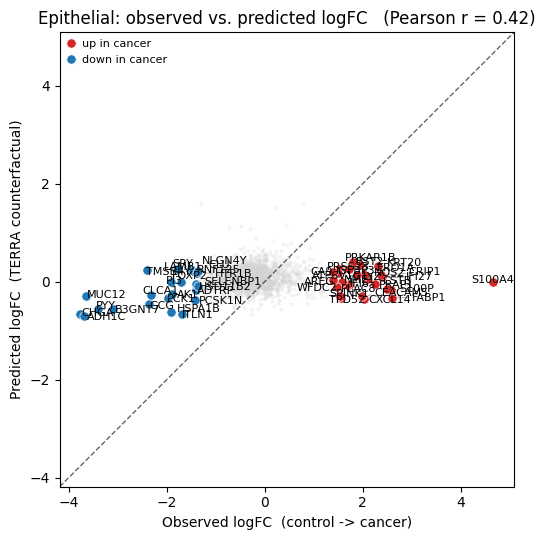

In [23]:
from adjustText import adjust_text

def plot_lfc(true_lfc, pred_lfc, deg, gene_names, holdout_ct, pearson):
    fig, ax = plt.subplots(figsize=(6, 5.5))
    deg = np.asarray(deg)
    non_deg = np.setdiff1d(np.arange(len(true_lfc)), deg)
    ax.scatter(true_lfc[non_deg], pred_lfc[non_deg], alpha=0.25, s=8,
               color="lightgray", linewidths=0, rasterized=True)
    up, down = deg[true_lfc[deg] >= 0], deg[true_lfc[deg] < 0]
    ax.scatter(true_lfc[up], pred_lfc[up], s=45, color="#d62728",
               edgecolor="white", linewidths=0.5, zorder=3, label="up in cancer")
    ax.scatter(true_lfc[down], pred_lfc[down], s=45, color="#1f77b4",
               edgecolor="white", linewidths=0.5, zorder=3, label="down in cancer")
    texts = [ax.text(true_lfc[i], pred_lfc[i], gene_names[i], fontsize=8) for i in deg]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="0.6", lw=0.5))
    lo, hi = float(min(true_lfc.min(), pred_lfc.min())), float(max(true_lfc.max(), pred_lfc.max()))
    pad = 0.05 * (hi - lo); lims = [lo - pad, hi + pad]
    ax.plot(lims, lims, "k--", lw=1, alpha=0.6, zorder=1)
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
    ax.set_xlabel("Observed logFC  (control -> cancer)")
    ax.set_ylabel("Predicted logFC  (TERRA counterfactual)")
    ax.set_title(f"{holdout_ct}: observed vs. predicted logFC   (Pearson r = {pearson:.2f})")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    fig.tight_layout()
    return fig

fig = plot_lfc(true_lfc, pred_lfc, deg, np.array(sub.var_names), HOLDOUT_CT, r)
fig.savefig(OUT / f"terra_node_pert_lfc_{TAG}.svg", bbox_inches="tight")
plt.show()

## Caveats

1. **The perturbation is modest by construction.** The 200 target genes carry a median ~7.7% of a cell's
   counts on this panel (median library size 643, ~496 genes detected), and only genes actually detected in a
   neighbour can be shifted. `N_PERT_GENES` is the knob: 500 -> ~13% of counts, 1000 -> ~19%. Re-running the
   sweep only re-perturbs and re-embeds the control cells (§9-10), which is minutes — §6 does not repeat.
2. **The decoder is a probe, not TERRA.** Always read the counterfactual *r* against the fidelity ceiling.
3. **No re-ranking after perturbation.** Token order was fixed at tokenisation by expression rank; shifting
   `gene_expr` does not reorder tokens. Inherent to perturbing a tokenised sequence post hoc.
4. **Zero-shot vs trained.** TERRA never trains on this slide; cellina does. These are not like-for-like
   capability numbers, and any eventual comparison should say so.